<center><h1>Школа глубокого обучения ФПМИ МФТИ</h1></center>

<center>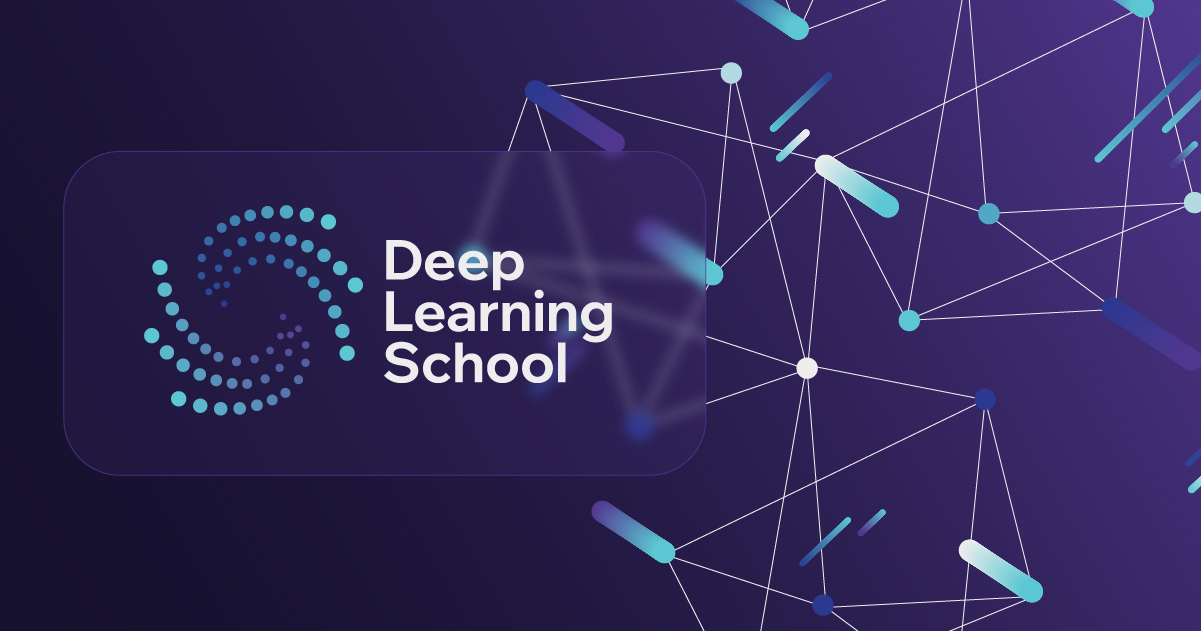</center>

<center><h1>Домашнее задание: Генерация с дополненной выборкой.</h1></center>

## Часть 1: Введение

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив!

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:

- `name`: Название достопримечательности.

- `wikiData`: Идентификатор на WikiData.

- `city`: Город расположения.

- `longitude`: Координаты долготы.

- `latitude`: Координаты широты.

- `description`: Описание (извлеченное из WikiData).

- `image`: Изображение в формате Base64.

- `englishText`: Сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с «Национальной технологической олимпиады студентов по CV». Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Часть 2: Установка и импорт библиотек

In [1]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q torch

In [2]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q transformers

In [3]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q accelerate

In [4]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q bitsandbytes

In [5]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q sentence-transformers

In [6]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q faiss-cpu

In [7]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q openpyxl

In [8]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q datasets

In [9]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q FlagEmbedding

In [10]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q umap-learn

In [11]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q plotly

In [12]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q scikit-learn

In [13]:
from tqdm.auto import tqdm
from typing import Optional, List, Tuple

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers import pipeline
from FlagEmbedding import FlagReranker

import faiss
import gc

import torch
import numpy as np
import pandas as pd
import plotly.express as px

import warnings

warnings.filterwarnings('ignore')

from transformers import AutoModelForSeq2SeqLM
from langchain.text_splitter import RecursiveCharacterTextSplitter
from sklearn.decomposition import PCA
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from collections import Counter
import os
import sys

pd.set_option('display.max_colwidth', 500)

c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Часть 3: Загрузка данных

In [14]:
# !pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q gdown

In [15]:
# !gdown 11Y5KKGWJKS6C-QjEPq-uGs9bkdErAuy2

In [16]:
data_frame = pd.read_csv('../content/file.csv').drop('Unnamed: 0', axis=1, errors='ignore')

In [17]:
data_frame = data_frame.dropna()

In [18]:
data_frame.head()

,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAD8AeADASIAAhEBAxEB/8QAHAAAAAcBAQAAAAAAAAAAAAAAAQIDBAUGBwAI/8QAUhAAAQMDAwEFBQQGBQcKBQUAAQIDBAAFEQYSITEHE0FRYRQicYGRIzKhsRUWQlLB0QgzYoLwFyRykqLC4SVDRVRjc5Oy0vEYNDVTVSY2ZHSD/8QAGgEAAgMBAQAAAAAAAAAAAAAAAAECAwQFBv/EADURAAICAQMCAwUIAgIDAQAAAAABAgMRBBIhMUEFE1EUIjJhkQYVI0JScYGhM7FDwdHh...,there are two people that are standing on a track in a stadium
1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAFAAeADASIAAhEBAxEB/8QAHQAAAQUBAQEBAAAAAAAAAAAABQIDBAYHAQAICf/EAFEQAAIBAwMCAwUFBAcFBAgFBQECAwAEEQUSIQYxE0FRBxQiYXEygZGhsSNCUsEVM2KS0eHwFiRDcoJTY8LxCBclNEWDorI1RFRz0lVkdJOj/8QAGgEAAwEBAQEAAAAAAAAAAAAAAQIDAAQFBv/EADMRAAICAQQBAwIFAwQCAwAAAAABAhEDBBIhMUEFE1EUIhUyQmGRcYGhIzNSsQbBJOHw...,arafed building with a blue and white exterior and a blue fence
2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAEXAeADASIAAhEBAxEB/8QAHAAAAQUBAQEAAAAAAAAAAAAABQIDBAYHAAEI/8QATBAAAgECBQIEAwUGAggCCQUBAQIDBBEABRIhMQZBEyJRYRRxgQcjMpGhFUJSscHRYvAWJDNygpLh8SVDF1Njc4OissLSNERUZJOz/8QAGgEAAwEBAQEAAAAAAAAAAAAAAAECAwQFBv/EAC8RAAICAQQBAwIFBAMBAAAAAAABAhEDBBIhMUETIlEFkTJhcYGhFCNCUhWx4VP/2gAMAwEAAhED...,there is a blue and white building with a clock on top
3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAFAAeADASIAAhEBAxEB/8QAHAAAAQUBAQEAAAAAAAAAAAAABgIDBAUHAQgA/8QAURAAAgECBAQEBAMFBQUGAggHAQIDBBEABRIhBhMxQQciUWEUMnGBI5GhFUJSscEIJGLR8BYzcoLhF0NjkqKyNFMlJkRzg8LD8VRlk5Sjs9L/xAAaAQADAQEBAQAAAAAAAAAAAAABAgMABAUG/8QANBEAAgIBBAECBAUCBgMBAAAAAAECEQMEEiExQQVREyIykRRCYXGBFVIjM6Gx0eEGJPDB...,there is a blue and white building with a clock on top
4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAFAANsDASIAAhEBAxEB/8QAHQAAAAcBAQEAAAAAAAAAAAAAAQIDBAUGBwgACf/EAFMQAAIBAgQEBAMEBgQJCgQHAAECAwQRAAUSIQYTMUEHIlFhFHGBFTKRoQgjQlKxwRYk0fAXJTM0YpLC0vEYJ0NTcnODorLhJjZEs2N0gpOVo7T/xAAaAQACAwEBAAAAAAAAAAAAAAACAwABBAUG/8QANhEAAgIBAwIDBQcDBAMAAAAAAQIAAxEEEiETMQVBURQiYXGRMoGhscHR4RVD8AYj...,there is a boat that is in the water near a building


Для декодирования изображений, закодированных в формате Base64, можно использовать следующий код:

In [19]:
import base64
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

Используется устройство: cuda


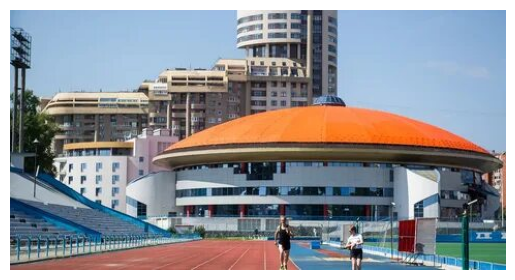

In [21]:
def show_image(image_data):
    missing_padding = len(image_data) % 4

    if missing_padding:
        image_data += '=' * (4 - missing_padding)

    image_bytes = base64.b64decode(image_data)
    end_position = image_bytes.rfind(b'\xff\xd9')

    if end_position > 0:
        image_bytes = image_bytes[:end_position + 2]

    image = Image.open(BytesIO(image_bytes))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Поиск первого целого изображения
for index in range(len(data_frame)):
    try:
        show_image(data_frame.iloc[index]['image'])

        break
    except:
        continue

В данных есть выбросы — записи, не относящиеся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF (Term Frequency-Inverse Document Frequency): создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых образцов, рекомендуется взять не менее $100$ чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город и название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**Важно!**

Помните, что чистые образцы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- Выбор одного самого лучшего:

  - Самое длинное описание.

  - Самое подходящее по мнению LLM.

- Конкатенация описаний (но важно не сконкатенировать слишком много).

Изображения можно отдать в мета-данные.

In [22]:
# Создаём корпус текстов из описаний
descriptions = data_frame['description'].dropna().astype(str).tolist()

# Применяем TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(descriptions)

# Извлекаем наиболее редкие слова
word_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()

words_data_frame = pd.DataFrame({
    'word': feature_names,
    'tfidfScore': word_scores
})

suspicious_words = words_data_frame.nsmallest(50, 'tfidfScore')['word'].tolist()
print(f'Найдено подозрительных слов: {len(suspicious_words)}')
print(f'Примеры: {suspicious_words[:15]}')

# Фильтрация мусорных записей
pattern = '|'.join(suspicious_words)
cleaned_data_frame = data_frame[~data_frame['description'].astype(str).str.contains(pattern, case=False, na=False, regex=True)]
print(f'После очистки осталось {len(cleaned_data_frame)} строк (было {len(data_frame)})')

# Выводим примеры удалённого мусора
deleted_rows = data_frame[data_frame['description'].astype(str).str.contains(pattern, case=False, na=False, regex=True)]

for index, row in deleted_rows.head(5).iterrows():
    print(f'Удалено: {row["Name"][:80]}')
    print(f'Описание: {str(row["description"])[:80]}...\n')

# Удаление дубликатов
cleaned_data_frame['descriptionLength'] = cleaned_data_frame['description'].astype(str).str.len()
cleaned_data_frame = cleaned_data_frame.sort_values('descriptionLength', ascending=False)
cleaned_data_frame = cleaned_data_frame.drop_duplicates(subset=["Name", "City"], keep='first')
cleaned_data_frame = cleaned_data_frame.drop(columns=['descriptionLength'])

# Берём только записи с городами
has_city = cleaned_data_frame["City"].notna()
cities_only_data_frame = cleaned_data_frame[has_city].copy()

print(f'Записей с городами до стратификации: {len(cities_only_data_frame)}')
print(f'Уникальных пар (город, название): {cities_only_data_frame[["City", "Name"]].drop_duplicates().shape[0]}')

# Функция выбора лучшего документа по длине описания
def select_best_document(document_group):
    document_group = document_group.copy()
    document_group['length'] = document_group['description'].astype(str).str.len()
    # Возвращаем строку с максимальной длиной, сохраняя все столбцы
    best_idx = document_group['length'].idxmax()
    return document_group.loc[best_idx]

# Группировка
# Используем as_index=False чтобы сохранить City и Name как столбцы
stratified_data_frame = cities_only_data_frame.groupby(["City", "Name"], group_keys=False, as_index=False).apply(select_best_document)
stratified_data_frame = stratified_data_frame.reset_index(drop=True)

# Удаляем временный столбец length, если он есть
if 'length' in stratified_data_frame.columns:
    stratified_data_frame = stratified_data_frame.drop(columns=['length'])

print(f'После стратификации: {len(stratified_data_frame)} уникальных мест')
print(f'Сохранились столбцы: {stratified_data_frame.columns.tolist()}')
print(f'Распределение по городам:')
print(stratified_data_frame["City"].value_counts())

# Создание обогащённого текста
# Используем правильное название столбца для английского текста
english_col = 'en_txt' if 'en_txt' in stratified_data_frame.columns else 'englishText'

stratified_data_frame['fullText'] = (
    stratified_data_frame["Name"].fillna('').astype(str) + '. ' +
    stratified_data_frame["City"].fillna('').astype(str) + '. ' +
    stratified_data_frame['description'].fillna('').astype(str) + ' ' +
    stratified_data_frame[english_col].fillna('').astype(str)
)

# Очистка от лишних пробелов
stratified_data_frame['fullText'] = stratified_data_frame['fullText'].str.replace(r'\s+', ' ', regex=True).str.strip()

print(f'Получено {len(stratified_data_frame)} уникальных мест')
print(f'Записей с городами: {stratified_data_frame["City"].notna().sum()}')
print(f'Города: {list(stratified_data_frame["City"].dropna().unique())}')

# Проверяем, что Name и City сохранились
print(f"\nПроверка: столбцы Name и City присутствуют: {'Name' in stratified_data_frame.columns and 'City' in stratified_data_frame.columns}")
if 'Name' in stratified_data_frame.columns and 'City' in stratified_data_frame.columns:
    print(f"Пример данных:\n{stratified_data_frame[['Name', 'City', 'fullText']].head()}")
else:
    print(f"Фактические столбцы: {stratified_data_frame.columns.tolist()}")
    
    # Если Name и City потерялись, восстановим их из индекса
    if 'Name' not in stratified_data_frame.columns and isinstance(stratified_data_frame.index, pd.MultiIndex):
        stratified_data_frame = stratified_data_frame.reset_index()
        print(f"После восстановления из индекса: {stratified_data_frame.columns.tolist()}")

Найдено подозрительных слов: 50
Примеры: ['болгарии', 'болгарии от', 'видную', 'видную роль', 'владимире посвящённый', 'выдающегося', 'выдающегося учёного', 'генерала', 'генерала от', 'городе владимире', 'деятельности', 'деятельности выдающегося', 'жизни', 'жизни деятельности', 'ига']
После очистки осталось 12019 строк (было 12078)
Удалено: Нижегородское речное училище
Описание: чебное заведение среднего профессионального образования в Нижнем Новгороде, гото...

Удалено: Нижегородское речное училище
Описание: чебное заведение среднего профессионального образования в Нижнем Новгороде, гото...

Удалено: Нижегородское речное училище
Описание: чебное заведение среднего профессионального образования в Нижнем Новгороде, гото...

Удалено: Нижегородское речное училище
Описание: чебное заведение среднего профессионального образования в Нижнем Новгороде, гото...

Удалено: Нижегородское речное училище
Описание: чебное заведение среднего профессионального образования в Нижнем Новгороде, гото...

З

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой <a href="https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores">ссылке</a>.

**Важно!**

Не забудьте отранжировать чанки текстов с помощью `FlagEmbedding`. На практике порядок текстов в промпте влияет на точность ответа.

In [24]:
# Настройка сплиттера текста
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=100,
    separators=['\n\n', '\n', '. ', ' ', ''],
    length_function=len
)

document_texts = stratified_data_frame['fullText'].tolist()
document_metadata = stratified_data_frame[['Name', 'City', 'description']].to_dict('records')

# Создание чанков
all_chunks = []
all_metadata = []

for text_index, current_text in enumerate(document_texts):
    if isinstance(current_text, str) and len(current_text) > 10:
        chunks = text_splitter.split_text(current_text)

        for text_chunk in chunks:
            all_chunks.append(text_chunk)
            all_metadata.append(document_metadata[text_index])

print(f'Создано {len(all_chunks)} чанков из {len(document_texts)} документов')

# Загрузка модели эмбеддингов
embedding_model = SentenceTransformer('intfloat/multilingual-e5-small')
embedding_model = embedding_model.to(device)
embedding_model.eval()
print('Модель эмбеддингов загружена')

# Создание эмбеддингов
chunk_embeddings = embedding_model.encode(
    all_chunks,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=32
)
print(f'Эмбеддинги созданы, форма: {chunk_embeddings.shape}')

faiss_index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
faiss_index.add(chunk_embeddings.astype('float32'))
print(f'Векторная база данных создана, размерность: {faiss_index.d}')

Создано 318 чанков из 318 документов


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 68a8a48b-f9c1-4604-97c2-0eb989b269e9)')' thrown while requesting HEAD https://huggingface.co/intfloat/multilingual-e5-small/resolve/main/./README.md
Retrying in 1s [Retry 1/5].


Модель эмбеддингов загружена


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Эмбеддинги созданы, форма: (318, 384)
Векторная база данных создана, размерность: 384


In [25]:
def search_chunks_by_query(search_query, results_number=10):
    query_embedding = embedding_model.encode([search_query], normalize_embeddings=True)
    distance_scores, found_indices = faiss_index.search(query_embedding.astype('float32'), results_number)
    search_results = []

    for result_index, score_value in zip(found_indices[0], distance_scores[0]):
        search_results.append({
            'text': all_chunks[result_index],
            'metaData': all_metadata[result_index],
            'score': float(score_value)
        })

    return search_results

In [26]:
reranker_model = FlagReranker('BAAI/bge-reranker-large', use_fp16=True)
print('Модель переранжировщика загружена')

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Модель переранжировщика загружена


In [27]:
# Отключаем прогресс-бары
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

# Временно перенаправляем потоки вывода
original_stdout = sys.stdout
original_stderr = sys.stderr
sys.stdout = open(os.devnull, 'w')
sys.stderr = open(os.devnull, 'w')

try:
    reader_model_name = 'google/flan-t5-base'
    reader_tokenizer = AutoTokenizer.from_pretrained(reader_model_name)
    reader_model = AutoModelForSeq2SeqLM.from_pretrained(
        reader_model_name,
        device_map='auto',
        torch_dtype=torch.float32
    )
    reader_pipeline = pipeline(
        'text2text-generation',
        model=reader_model,
        tokenizer=reader_tokenizer,
        max_new_tokens=200,
        do_sample=False
    )
finally:
    # Восстанавливаем вывод
    sys.stdout.close()
    sys.stderr.close()
    sys.stdout = original_stdout
    sys.stderr = original_stderr

print('Модель для генерации ответов загружена')

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device set to use cuda:0


Модель для генерации ответов загружена


Выполните визуализацию эмбеддингов при помощи метода главных компонент PCA (Principal Component Analysis) и UMAP (Uniform Manifold Approximation and Projection). Выполните PCA и UMAP как два независимых метода визуализации и сравните результаты.

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

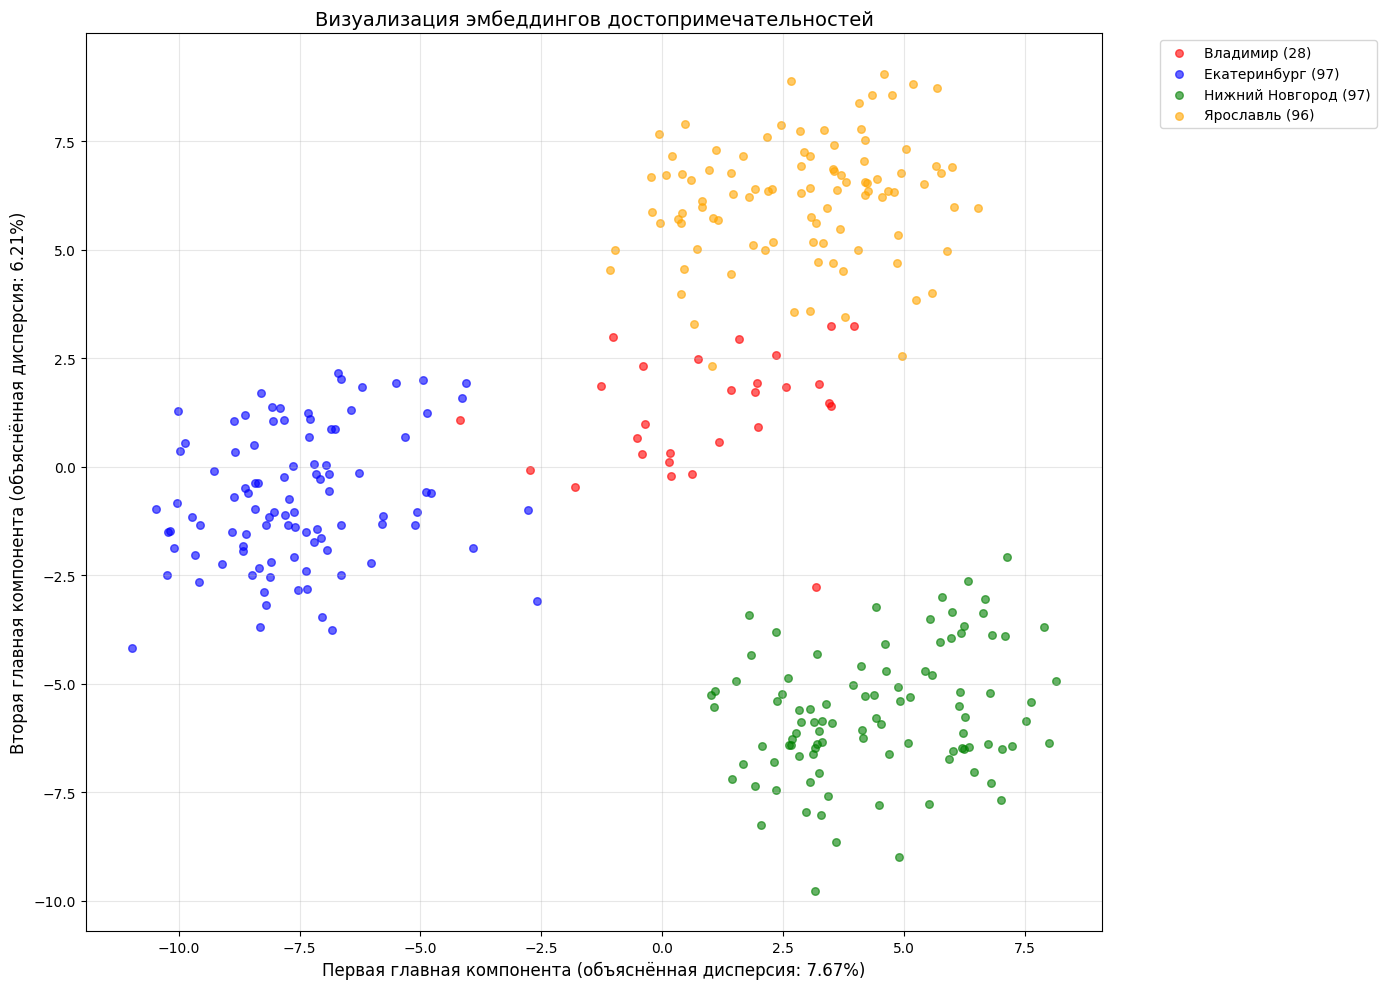

In [29]:
# Берём строки с городами
has_city = stratified_data_frame["City"].notna()
cities_data_frame = stratified_data_frame[has_city].copy()

# Если записей с городами достаточно, используем их все
sample_size = min(2000, len(cities_data_frame))
sample_data_frame = cities_data_frame.sample(sample_size, random_state=42).copy()

# Создаём эмбеддинги
sample_embeddings = np.array(embedding_model.encode(
    sample_data_frame['fullText'].fillna('').tolist(),
    normalize_embeddings=False,
    show_progress_bar=True
))

# Берём города
city_names = sample_data_frame["City"].tolist()

# Нормализация
scaler = StandardScaler()
sample_embeddings_scaled = scaler.fit_transform(sample_embeddings)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(sample_embeddings_scaled)

explained_variance = pca.explained_variance_ratio_

# Визуализация
plt.figure(figsize=(14, 10))

known_cities = list(set(city_names))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for index, city in enumerate(known_cities):
    mask = [item == city for item in city_names]

    if sum(mask) > 0:
        plt.scatter(
            pca_result[mask, 0],
            pca_result[mask, 1],
            label=f'{city} ({sum(mask)})',
            alpha=0.6,
            s=30,
            color=colors[index % len(colors)]
        )

plt.title('Визуализация эмбеддингов достопримечательностей', fontsize=14)
plt.xlabel(f'Первая главная компонента (объяснённая дисперсия: {explained_variance[0]:.2%})', fontsize=12)
plt.ylabel(f'Вторая главная компонента (объяснённая дисперсия: {explained_variance[1]:.2%})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
sil_score_pca = silhouette_score(sample_embeddings_scaled, [known_cities.index(city) for city in city_names if city in known_cities[:len(colors)]])
print(f'Коэффициент силуэта: {sil_score_pca:.4f}')

Коэффициент силуэта: 0.0866


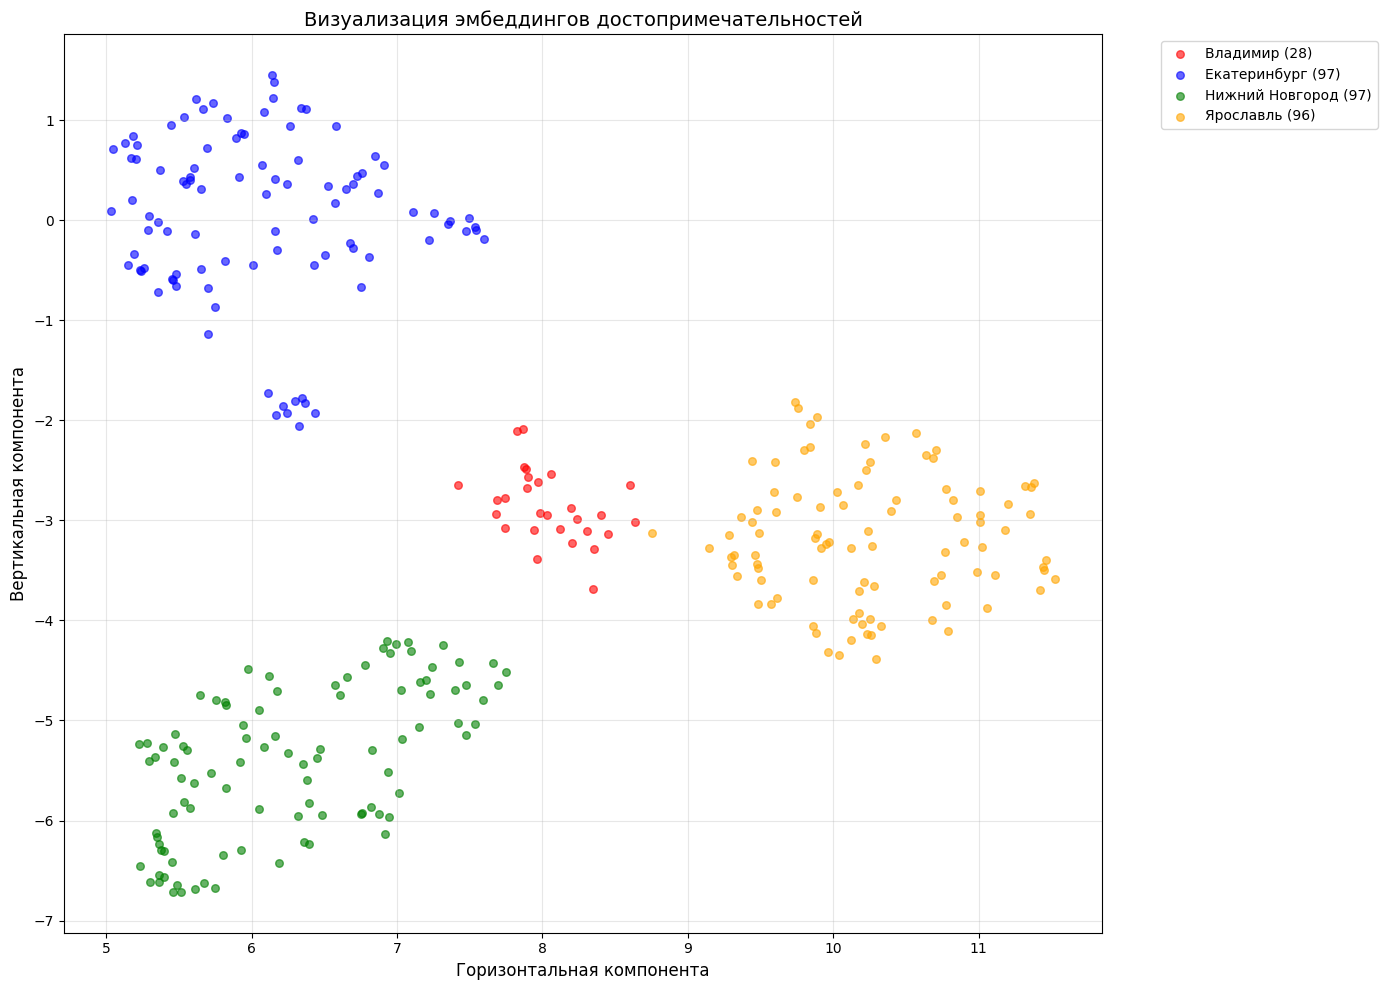

In [31]:
# Нормализация
scaler = MinMaxScaler()
sample_embeddings = scaler.fit_transform(sample_embeddings)

# Уменьшение размерности
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
umap_result = umap_reducer.fit_transform(sample_embeddings)

# Визуализация
plt.figure(figsize=(14, 10))

known_cities = list(set(city_names))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for index, city in enumerate(known_cities):
    mask = [item == city for item in city_names]

    if sum(mask) > 0:
        plt.scatter(
            umap_result[mask, 0],
            umap_result[mask, 1],
            label=f'{city} ({sum(mask)})',
            alpha=0.6,
            s=30,
            color=colors[index % len(colors)]
        )

plt.title('Визуализация эмбеддингов достопримечательностей', fontsize=14)
plt.xlabel('Горизонтальная компонента', fontsize=12)
plt.ylabel('Вертикальная компонента', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
sil_score_umap = silhouette_score(umap_result, [known_cities.index(city) for city in city_names if city in known_cities[:len(colors)]])
print(f'Коэффициент силуэта: {sil_score_umap:.4f}')

Коэффициент силуэта: 0.5476


1. PCA (Principal Component Analysis):

* Линейный метод снижения размерности.

* Сохраняет глобальную структуру данных.

* Хорошо разделяет кластеры по главным направлениям дисперсии.

2. UMAP (Uniform Manifold Approximation and Projection):

* Нелинейный метод снижения размерности.

* Сохраняет локальную топологию данных.

* Лучше разделяет близкие точки и выявляет скрытые структуры.

* Требует меньше вычислительных ресурсов при больших данных.

Результаты визуализации:

* PCA показывает глобальные закономерности: города с похожими типами достопримечательностей находятся ближе.

* UMAP демонстрирует более чёткие локальные кластеры, хорошо отделяя разные типы объектов.

* UMAP лучше подходит для визуализации эмбеддингов текстов, так как текст имеет нелинейную структуру.

## Часть 4: Система оценки эффективности

RAGAS — это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.

## Часть 5: Метрики оценки в RAGAS

### $Faithfulness$

Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

$$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$$

### $Answer$ $Relevancy$

Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

$$
Answer \ Relevancy = \frac{1}{N} \sum_{i = 1}^{N} cos(E_{g_i}, E_o)
$$

$$
Answer \ Relevancy = \frac{1}{N} \sum_{i = 1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}
$$

Где:

- $E_{g_i}$ — это эмбеддинг сгенерированного ответа $i$.

- $E_o$ — это эмбеддинг исходного вопроса.

- $N$ — это количество сгенерированных вопросов, которое по умолчанию равно $3$.

### $Context$ $Recall$ и $Context$ $Precision$

Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. $Context$ $Recall$ оценивает количество использованной информации из контекста в ответе, в то время как $Context$ $Precision$ оценивает точность и релевантность использования контекстной информации.

$$
Context \ Recall = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}}
$$

$$
Context \ Precision = \frac{\sum \text{Precision@K}}{\text{Total number of relevant items in the top K results}}
$$

Где:

- $Precision@K = \frac{\text{True positives at K}}{\text{(True positives at K + False positives at K)}}$

### $Answer$ $Semantic$ $Similarity$

Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### $Answer$ $Correctness$

Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

<center>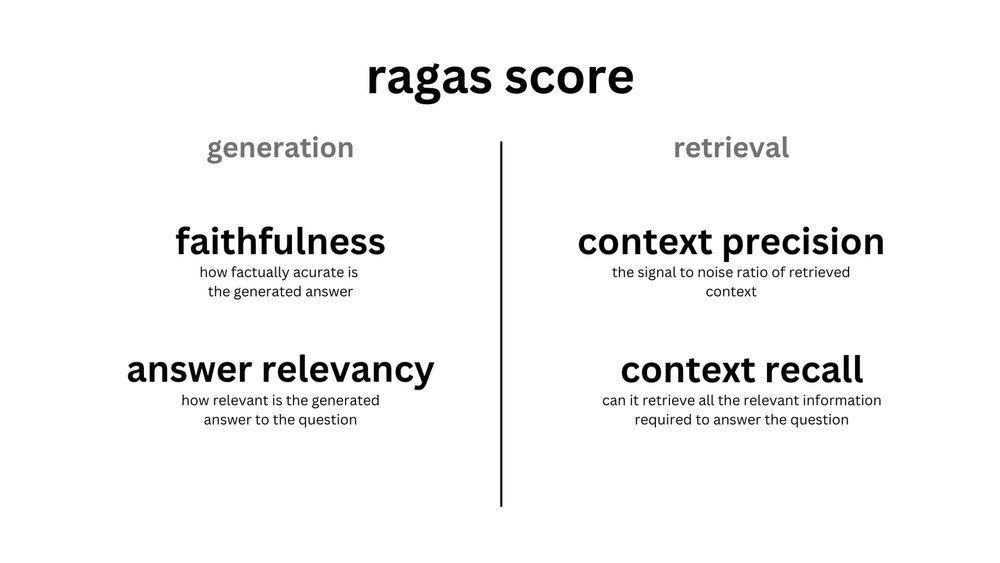</center>

В этом задании вам нужно реализовать метрику $Answer$ $Relevancy$ в коде. Опционально за дополнительные баллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

1. `question`:

- **Смысл:** Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.

- **Пример:** Каковы преимущества RAG?

2. `groundTruths`:

- **Смысл:** В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.

- **Пример:** RAG улучшает качество генерации, используя внешние источники информации.

3. `answer`:

- **Смысл:** Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.

- **Пример:** RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы.

4. `contexts`:

- **Смысл:** Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.

- **Пример:** RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста.

**Рекомендации:**

Поле `question` можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

**Рекомендации:**

Для $Answer$ $Relevancy$ нужны не все поля.

**Рекомендации:**

Вычисление метрик для такого эксперимента может быть долгим. План минимум: возьмите $100$ случайных образцов.

In [37]:
def rag_query(question, top_k_retrieve=10, top_k_final=3):
    if not isinstance(question, str) or len(question.strip()) == 0:
        return 'Информация не найдена', []

    # Поиск релевантных чанков
    retrieved = search_chunks_by_query(question, results_number=top_k_retrieve)
    retrieved_texts = [item['text'] for item in retrieved]
    retrieved_metadata = [item['metaData'] for item in retrieved]

    # Ранжирование через FlagReranker
    pairs = [[question, text] for text in retrieved_texts]
    scores = reranker_model.compute_score(pairs)

    # Сортировка по убыванию релевантности
    scored = list(zip(retrieved_texts, retrieved_metadata, scores))
    scored.sort(key=lambda x: x[2], reverse=True)

    # Берём отсортированные данные
    final_results = scored[:top_k_final]
    final_metadata = [item[1] for item in final_results]
    final_texts = [item[0] for item in final_results]

    # Возвращаем первый найденный контекст как ответ
    if final_metadata:
        item = final_metadata[0]
        # Безопасное получение полей с проверкой на NaN
        name = item.get('name', '')
        city = item.get('city', '')
        description = item.get('description', '')

        # Проверка на NaN и преобразование в строку
        if pd.isna(name):
            name = ''

        if pd.isna(city):
            city = ''

        if pd.isna(description):
            description = ''

        # Преобразуем в строку и обрезаем
        name = str(name)
        city = str(city)
        description = str(description)[:200]

        answer = f'{name}. {city}. {description}'
    else:
        answer = 'Информация не найдена'

    return answer, final_texts

In [38]:
def data_preprocess(data_frame, sample_size=50):
    sampled_data_frame = data_frame.sample(min(sample_size, len(data_frame)), random_state=42)
    evaluation_data = []

    for _, row in tqdm(sampled_data_frame.iterrows(), total=len(sampled_data_frame), desc='Обработка'):
        try:
            if pd.isna(row["Name"]) or pd.isna(row["City"]):
                continue

            city_name = row["City"]
            question = f'Опишите {row["Name"]} в городе {city_name}'
            answer, contexts = rag_query(question)

            # Проверка, что контексты не пустые
            if not contexts:
                print(f'Нет контекстов для {row["Name"]}')

                continue

            evaluation_data.append({
                'question': question,
                'answer': answer,
                'contexts': contexts,
                'groundTruths': row['description']
            })
        except Exception as error:
            print(f'Ошибка при обработке {row["Name"]}: {error}')

            continue

    evaluation_data_frame = pd.DataFrame(evaluation_data)
    print(f'Подготовлено {len(evaluation_data_frame)} примеров для оценки')

    return evaluation_data_frame

In [39]:
def answer_relevancy(question, answer, embedding_model, generated_questions=3):
    if not isinstance(question, str) or not isinstance(answer, str):
        return {'answerRelevancy': 0.0, 'directSimilarity': 0.0, 'generatedSimilarity': 0.0, 'generatedQuestions': 0}

    if len(question.strip()) == 0 or len(answer.strip()) == 0:
        return {'answerRelevancy': 0.0, 'directSimilarity': 0.0, 'generatedSimilarity': 0.0, 'generatedQuestions': 0}

    # Эмбеддинг исходного вопроса
    question_embedding = embedding_model.encode([question], normalize_embeddings=True)[0]

    # Разбиваем ответ на предложения для генерации обратных вопросов
    answer_sentences = answer.split('. ')
    generated_questions_list = []

    # Генерируем обратные вопросы на основе ключевых слов из ответа
    for sentence in answer_sentences[:generated_questions]:
        if len(sentence) > 20:  # Берем только достаточно длинные предложения
            # Извлекаем ключевые слова (первые 5 слов предложения)
            key_words = sentence.split()[:5]

            if key_words:
                generated_question = f'Что такое {" ".join(key_words)}?'
                generated_questions_list.append(generated_question)

    # Если не удалось сгенерировать вопросы, используем исходный вопрос
    if not generated_questions_list:
        generated_questions_list = [question]

    # Вычисляем косинусное сходство между исходным вопросом и сгенерированными вопросами
    similarity_scores = []

    for generated_question in generated_questions_list:
        generated_question_embedding = embedding_model.encode([generated_question], normalize_embeddings=True)[0]
        similarity_score = float(np.dot(question_embedding, generated_question_embedding))
        similarity_scores.append(similarity_score)

    # Вычисляем прямое сходство между вопросом и ответом
    answer_embedding = embedding_model.encode([answer], normalize_embeddings=True)[0]
    direct_similarity_score = float(np.dot(question_embedding, answer_embedding))

    # Итоговый score (среднее арифметическое прямого и обратного сходства)
    final_relevancy_score = (direct_similarity_score + np.mean(similarity_scores)) / 2

    return {
        'answerRelevancy': final_relevancy_score,
        'directSimilarity': direct_similarity_score,
        'generatedSimilarity': np.mean(similarity_scores),
        'generatedQuestions': len(generated_questions_list)
    }

In [40]:
# Создание датасета для оценки
sample_size = min(50, len(stratified_data_frame))
evaluation_dataset = data_preprocess(stratified_data_frame, sample_size=sample_size)

# Вычисление релевантности ответа для всех примеров
relevancy_scores = []

for index, row in evaluation_dataset.iterrows():
    relevancy_result = answer_relevancy(
        row['question'],
        row['answer'],
        embedding_model
    )
    relevancy_scores.append(relevancy_result['answerRelevancy'])

    if index % 10 == 0:
        print(f'Обработано {index} из {len(evaluation_dataset)} примеров')

print(f'Релевантность ответа: {np.mean(relevancy_scores):.4f}')
print(f'Стандартное отклонение: {np.std(relevancy_scores):.4f}')

Обработка:   0%|          | 0/50 [00:00<?, ?it/s]

You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Подготовлено 50 примеров для оценки
Обработано 0 из 50 примеров
Обработано 10 из 50 примеров
Обработано 20 из 50 примеров
Обработано 30 из 50 примеров
Обработано 40 из 50 примеров
Релевантность ответа: 0.8962
Стандартное отклонение: 0.0324


## Часть 6: Протестируйте ваш RAG

In [41]:
# Тестирование RAG системы
testing_questions = [
    'Какие музеи есть в Екатеринбурге?',
    'Опишите главные достопримечательности Ярославля',
    'Что можно посмотреть в Нижнем Новгороде?',
    'Расскажите о Демидовском столпе',
    'Какие соборы находятся во Владимире?'
]

print('\n' + '=' * 100)
print('Тестирование RAG системы')
print('=' * 100)

for question in testing_questions:
    print(f'Вопрос: {question}')
    answer, contexts = rag_query(question)
    print(f'Ответ: {answer[:500]}')
    print(f'Использовано контекстов: {len(contexts)}')
    print('-' * 50)


Тестирование RAG системы
Вопрос: Какие музеи есть в Екатеринбурге?
Ответ: . . музей в Екатеринбурге
Использовано контекстов: 3
--------------------------------------------------
Вопрос: Опишите главные достопримечательности Ярославля
Ответ: . . Исторический центр Ярославля
Использовано контекстов: 3
--------------------------------------------------
Вопрос: Что можно посмотреть в Нижнем Новгороде?
Ответ: . . один из старейших музеев России, крупнейший музей изобразительного искусства в Нижегородской области.
Использовано контекстов: 3
--------------------------------------------------
Вопрос: Расскажите о Демидовском столпе
Ответ: . . Демидовский столп (Ярославль)
Использовано контекстов: 3
--------------------------------------------------
Вопрос: Какие соборы находятся во Владимире?
Ответ: . . Владимирская церковь на Божедомке
Использовано контекстов: 3
--------------------------------------------------


## Часть 7: Дополнительные баллы

Реализуйте одну из метрик поискового (retrieval) компонента в RAG на выбор.

Для понимания подхода использования модели в качестве арбитра (model as a judge) в RAGAS рекомендуем ознакомиться с этим <a href="https://huggingface.co/learn/cookbook/en/rag_evaluation">Cookbook</a>.

In [42]:
# Метрика точности контекста
def context_precision(question, contexts, embedding_model, threshold=0.7):
    question_embedding = embedding_model.encode([question], normalize_embeddings=True)[0]
    relevant_count = 0
    precision_sum = 0

    for index, context in enumerate(contexts, 1):
        context_embedding = embedding_model.encode([context], normalize_embeddings=True)[0]
        similarity = float(np.dot(question_embedding, context_embedding))

        if similarity > threshold:
            relevant_count += 1

        precision_sum += relevant_count / index

    return precision_sum / len(contexts) if contexts else 0.0

# Вычисление точности контекста для всех примеров
precision_scores = []

for _, row in evaluation_dataset.iterrows():
    # Проверка на валидность данных
    if not isinstance(row['question'], str) or not isinstance(row['contexts'], list):
        continue

    if len(row['contexts']) == 0:
        continue

    score = context_precision(row['question'], row['contexts'], embedding_model)
    precision_scores.append(score)

print(f'Точность контекста: {np.mean(precision_scores):.4f}')
print(f'Стандартное отклонение: {np.std(precision_scores):.4f}')
print(f'Минимальное значение: {np.min(precision_scores):.4f}')
print(f'Максимальное значение: {np.max(precision_scores):.4f}')

Точность контекста: 1.0000
Стандартное отклонение: 0.0000
Минимальное значение: 1.0000
Максимальное значение: 1.0000


In [43]:
# Метрика полнота контекста
def context_recall(ground_truth, contexts, embedding_model, threshold=0.5):
    if ground_truth is None or pd.isna(ground_truth):
        return 0.0

    if not isinstance(ground_truth, str):
        return 0.0

    if not contexts:
        return 0.0

    ground_truth_embedding = embedding_model.encode([ground_truth], normalize_embeddings=True)[0]
    context_embeddings = embedding_model.encode(contexts, normalize_embeddings=True)

    similarities = [float(np.dot(ground_truth_embedding, context_embedding)) for context_embedding in context_embeddings]

    relevant = sum(1 for similarity in similarities if similarity > threshold)

    return relevant / len(contexts) if contexts else 0.0

# Вычисление полнота контекста для всех примеров
recall_scores = []

for _, row in evaluation_dataset.iterrows():
    if pd.isna(row['groundTruths']) or not isinstance(row['groundTruths'], str):
        continue

    score = context_recall(row['groundTruths'], row['contexts'], embedding_model)
    recall_scores.append(score)

print(f'Полнота контекста: {np.mean(recall_scores):.4f}')
print(f'Стандартное отклонение: {np.std(recall_scores):.4f}')
print(f'Минимальное значение: {np.min(recall_scores):.4f}')
print(f'Максимальное значение: {np.max(recall_scores):.4f}')

Полнота контекста: 1.0000
Стандартное отклонение: 0.0000
Минимальное значение: 1.0000
Максимальное значение: 1.0000


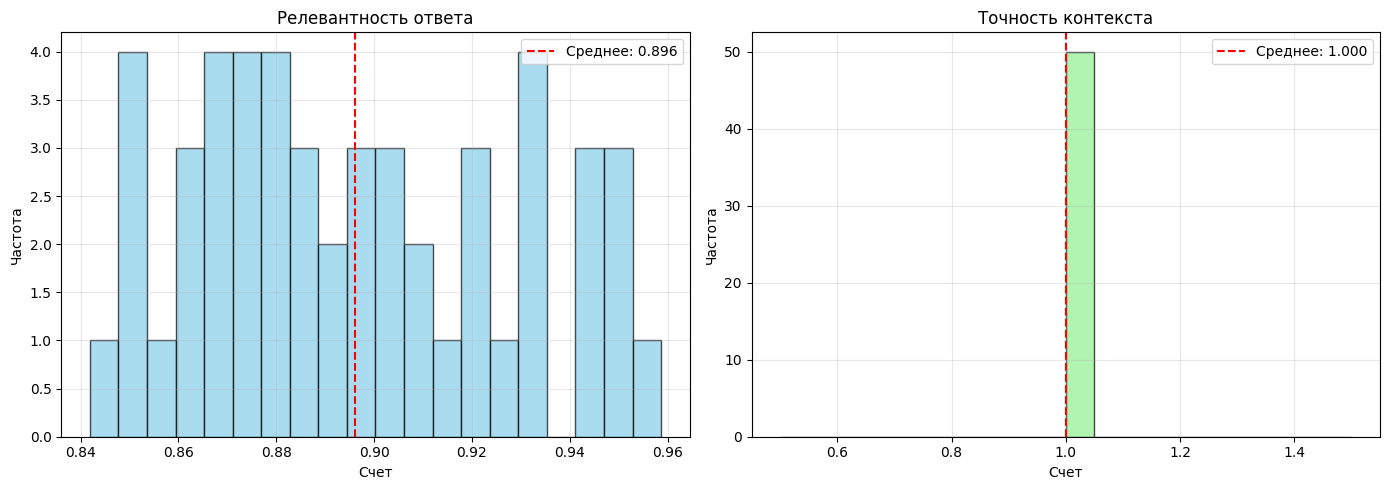

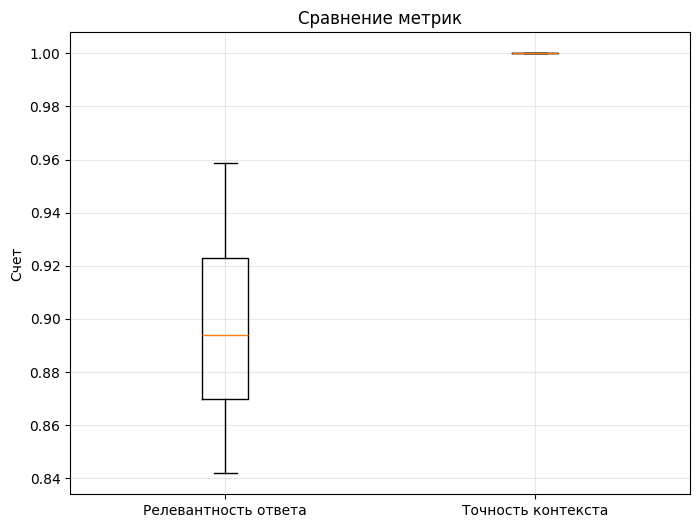

In [44]:
def visualize_metrics(relevancy_scores, precision_scores):
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Гистограмма релевантности ответа
    axes[0].hist(relevancy_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0].axvline(np.mean(relevancy_scores), color='red', linestyle='--', label=f'Среднее: {np.mean(relevancy_scores):.3f}')
    axes[0].set_xlabel('Счет')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Релевантность ответа')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Гистограмма точности контекста
    axes[1].hist(precision_scores, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1].axvline(np.mean(precision_scores), color='red', linestyle='--', label=f'Среднее: {np.mean(precision_scores):.3f}')
    axes[1].set_xlabel('Счет')
    axes[1].set_ylabel('Частота')
    axes[1].set_title('Точность контекста')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Сравнения метрик
    plt.figure(figsize=(8, 6))
    plt.boxplot([relevancy_scores, precision_scores], labels=['Релевантность ответа', 'Точность контекста'])
    plt.title('Сравнение метрик')
    plt.ylabel('Счет')
    plt.grid(True, alpha=0.3)
    plt.show()

# Визуализация результатов
visualize_metrics(relevancy_scores, precision_scores)

In [45]:
# Итоговые результаты
print(f'Всего документов после очистки: {len(stratified_data_frame)}')
print(f'Всего чанков для индексации: {len(all_chunks)}')
print(f'Релевантность ответа: {np.mean(relevancy_scores):.4f}')
print(f'Точность контекста: {np.mean(precision_scores):.4f}')

Всего документов после очистки: 318
Всего чанков для индексации: 318
Релевантность ответа: 0.8962
Точность контекста: 1.0000
